In [4]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('weatherHistory.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)


Dataset loaded successfully!
Shape: (96453, 12)


In [5]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [3]:
df.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [8]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [17]:
# Fill missing Precip Type with 'Unknown'
df['Precip Type'].fillna('Unknown', inplace=True)

# Convert Formatted Date to datetime format
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], c)

# Extract Year and Month as separate columns
df['Year'] = df['Formatted Date'].dt.year
df['Month'] = df['Formatted Date'].dt.month

print("Cleaning done!")
print("Missing values remaining per column:", df.isnull().sum())

Cleaning done!
Missing values remaining per column: Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
Year                        0
Month                       0
dtype: int64


In [18]:
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


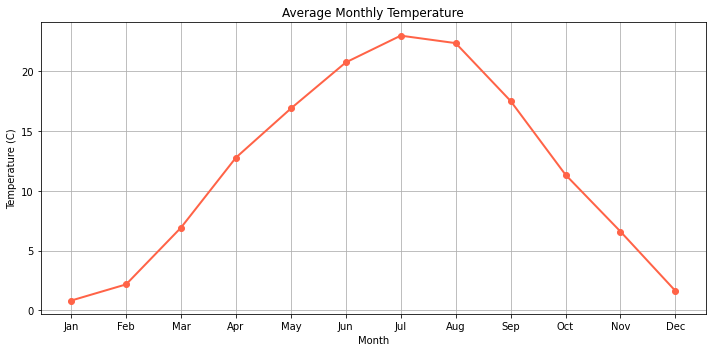

In [37]:
monthly_temp = df.groupby('Month')['Temperature (C)'].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_temp.index, monthly_temp.values, marker='o', color='tomato', linewidth=2)
plt.title('Average Monthly Temperature')
plt.xlabel('Month')
plt.ylabel('Temperature (C)')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.tight_layout()
plt.show()

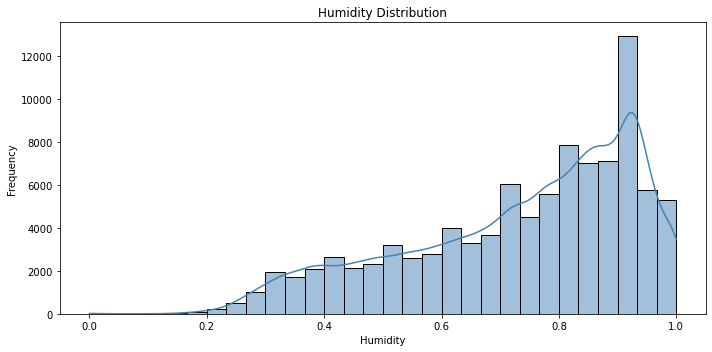

In [39]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Humidity'], bins=30, color='steelblue', kde=True) 
#kde -- kernel density estimate -- smooth curve drawn over the bars
plt.title('Humidity Distribution')
plt.xlabel('Humidity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

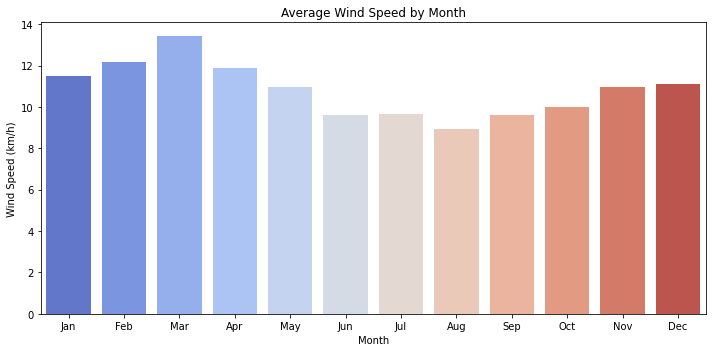

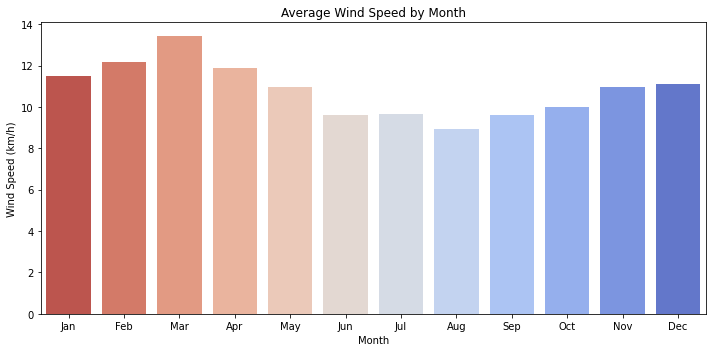

In [41]:
monthly_wind = df.groupby('Month')['Wind Speed (km/h)'].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_wind.index, y=monthly_wind.values, palette='coolwarm')
plt.title('Average Wind Speed by Month')
plt.xlabel('Month')
plt.ylabel('Wind Speed (km/h)')
plt.xticks(range(0, 12), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

## reverse palette order

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_wind.index, y=monthly_wind.values, palette='coolwarm_r')
plt.title('Average Wind Speed by Month')
plt.xlabel('Month')
plt.ylabel('Wind Speed (km/h)')
plt.xticks(range(0, 12), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

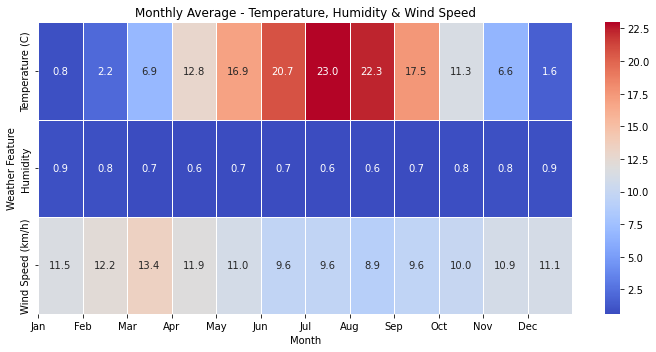

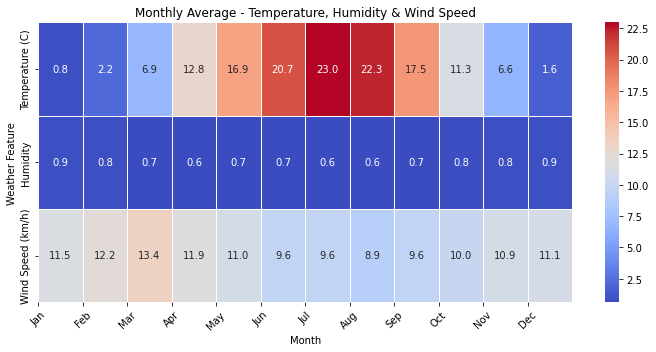

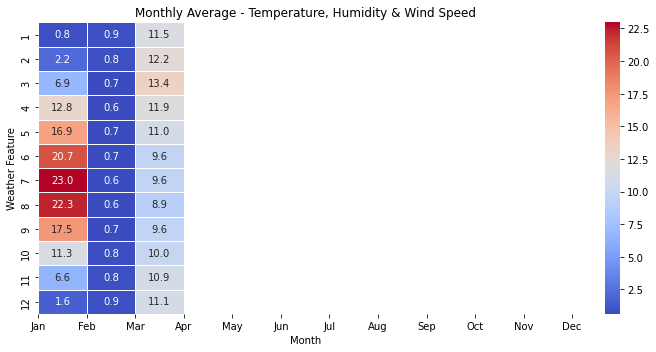

In [50]:
monthly_data = df.groupby('Month')[['Temperature (C)', 
                'Humidity', 'Wind Speed (km/h)']].mean()

plt.figure(figsize=(10, 5))
sns.heatmap(monthly_data.T, annot=True, fmt='.1f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Monthly Average - Temperature, Humidity & Wind Speed')
plt.xlabel('Month')
plt.ylabel('Weather Feature')
plt.xticks(ticks=range(0, 12), labels=['Jan','Feb','Mar','Apr','May',
           'Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()

# with tranformation , but rotation 45 

plt.figure(figsize=(10, 5))
sns.heatmap(monthly_data.T, annot=True, fmt='.1f', 
            cmap='coolwarm', linewidths=0.5)
plt.title('Monthly Average - Temperature, Humidity & Wind Speed')
plt.xlabel('Month')
plt.ylabel('Weather Feature')
plt.xticks(ticks=range(0, 12), labels=['Jan','Feb','Mar','Apr','May',
           'Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.show()


#without tranfering row and cloumn
plt.figure(figsize=(10, 5))
sns.heatmap(monthly_data, annot=True, fmt='.1f', 
            cmap='coolwarm', linewidths=0.5)

plt.title('Monthly Average - Temperature, Humidity & Wind Speed')
plt.xlabel('Month')
plt.ylabel('Weather Feature')
plt.xticks(ticks=range(0, 12), labels=['Jan','Feb','Mar','Apr','May',
           'Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.show()

In [51]:
print("=" * 50)
print("WEATHER DATA ANALYSIS - KEY FINDINGS")
print("=" * 50)

print("\n1. TEMPERATURE:")
print(f"   Hottest Month : Month {monthly_temp.idxmax()} with {monthly_temp.max():.1f}°C")
print(f"   Coldest Month : Month {monthly_temp.idxmin()} with {monthly_temp.min():.1f}°C")

print("\n2. HUMIDITY:")
print(f"   Average Humidity : {df['Humidity'].mean():.2f}")
high_humidity = (df['Humidity'] > 0.7).sum()
percentage = (high_humidity / len(df)) * 100
print(f"   High Humidity Days (>0.7) : {percentage:.1f}% of total records")

print("\n3. WIND SPEED:")
print(f"   Highest Wind Month : Month {monthly_wind.idxmax()} with {monthly_wind.max():.1f} km/h")
print(f"   Lowest Wind Month  : Month {monthly_wind.idxmin()} with {monthly_wind.min():.1f} km/h")

print("\n4. OVERALL PATTERN:")
print("   Temperature peaks in summer months and drops in winter")
print("   Humidity remains consistently high throughout the year")
print("   Wind speed varies moderately across months")

print("\n" + "=" * 50)
print("Analysis Complete!")
print("=" * 50)

WEATHER DATA ANALYSIS - KEY FINDINGS

1. TEMPERATURE:
   Hottest Month : Month 7 with 23.0°C
   Coldest Month : Month 1 with 0.8°C

2. HUMIDITY:
   Average Humidity : 0.73
   High Humidity Days (>0.7) : 63.1% of total records

3. WIND SPEED:
   Highest Wind Month : Month 3 with 13.4 km/h
   Lowest Wind Month  : Month 8 with 8.9 km/h

4. OVERALL PATTERN:
   Temperature peaks in summer months and drops in winter
   Humidity remains consistently high throughout the year
   Wind speed varies moderately across months

Analysis Complete!
